# Lab thực hành: Mạng thần kinh để nhận dạng chữ số viết tay, nhị phân

Trong bài tập này, bạn sẽ sử dụng neural network để nhận dạng các chữ số viết tay bằng 0 và 1.


# Phác thảo
- [ 1 - Packages ](#1)
- [ 2 - Neural Networks](#2)
  - [ 2.1 Problem Statement](#2.1)
  - [ 2.2 Dataset](#2.2)
  - [ 2.3 Model representation](#2.3)
  - [ 2.4 Tensorflow Model Implementation](#2.4)
    - [ Exercise 1](#ex01)
  - [ 2.5 NumPy Model Implementation (Forward Prop in NumPy)](#2.5)
    - [ Exercise 2](#ex02)
  - [ 2.6 Vectorized NumPy Model Implementation (Optional)](#2.6)
    - [ Exercise 3](#ex03)
  - [ 2.7 Congratulations!](#2.7)
  - [ 2.8 NumPy Broadcasting Tutorial (Optional)](#2.8)


<a name="1"></a>
## 1 - Package 

Trước tiên, hãy chạy ô bên dưới để nhập tất cả các gói mà bạn sẽ cần trong nhiệm vụ này.
- [numpy](https://numpy.org/) là gói cơ bản dành cho máy tính khoa học với Python.
- [matplotlib](http://matplotlib.org) là thư viện phổ biến để vẽ đồ thị trong Python.
- [tensorflow](https://www.tensorflow.org/) một nền tảng phổ biến cho học máy.


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from autils import *
%matplotlib inline

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

2026-06-22 09:37:25.220368: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-22 09:37:25.252997: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-22 09:37:25.253573: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-22 09:37:25.859093: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


** Tensorflow và Keras **  
Tensorflow là gói máy học được phát triển bởi Google. Năm 2019, Google đã tích hợp Keras vào Tensorflow và phát hành Tensorflow 2.0. Keras là một framework được phát triển độc lập bởi François Chollet nhằm tạo ra giao diện đơn giản, tập trung vào lớp cho Tensorflow. Khóa học này sẽ sử dụng giao diện Keras.


<a name="2"></a>
## 2 - Mạng thần kinh

Trong Khóa 1, bạn đã triển khai logistic regression. Điều này đã được mở rộng để xử lý các ranh giới phi tuyến tính bằng cách sử dụng hồi quy đa thức. Đối với các trường hợp phức tạp hơn nữa như nhận dạng hình ảnh, neural network được ưu tiên hơn.

<a name="2.1"></a>
### 2.1 Bài toán

Trong bài tập này, bạn sẽ sử dụng neural network để nhận dạng hai chữ số viết tay, số 0 và số một. Đây là một nhiệm vụ phân loại nhị phân. Nhận dạng chữ số viết tay tự động được sử dụng rộng rãi ngày nay - từ nhận dạng mã zip (mã bưu chính) trên phong bì thư đến nhận dạng số tiền viết trên séc ngân hàng. Bạn sẽ mở rộng mạng này để nhận dạng tất cả 10 chữ số (0-9) trong bài tập sau này. 

Bài tập này sẽ chỉ cho bạn cách sử dụng các phương pháp bạn đã học cho nhiệm vụ phân loại này.

<a name="2.2"></a>
### 2.2 Bộ dữ liệu

Bạn sẽ bắt đầu bằng cách tải tập dữ liệu cho tác vụ này. 
- Hàm `load_data()` hiển thị bên dưới tải dữ liệu vào các biến `X` và `y`


- Bộ dữ liệu chứa 1000 training example về các chữ số viết tay $^1$, ở đây giới hạn ở 0 và một.  

    - Mỗi training example là một ảnh thang độ xám 20 pixel x 20 pixel của chữ số. 
        - Mỗi pixel được biểu thị bằng một số dấu phẩy động cho biết cường độ thang độ xám tại vị trí đó. 
        - Lưới 20 x 20 pixel được “trải” thành một vectơ 400 chiều. 
        - Mỗi traning example sẽ trở thành một hàng trong ma trận dữ liệu của chúng ta `X`. 
        - Điều này mang lại cho chúng ta một ma trận 1000 x 400 `X` trong đó mỗi hàng là một traning example về hình ảnh chữ số viết tay.

$$X = 
\left(\begin{array}{cc} 
--- (x^{(1)}) --- \\
--- (x^{(2)}) --- \\
\vdots \\ 
--- (x^{(m)}) --- 
\end{array}\right)$$ 

- Phần thứ hai của tập training là vectơ 1000 x 1 chiều `y` chứa các nhãn cho tập training
    - `y = 0` nếu ảnh là chữ số `0`, `y = 1` nếu ảnh là chữ số `1`.

$^1$<sub> Đây là tập hợp con của tập dữ liệu chữ số viết tay MNIST (http://yann.lecun.com/exdb/mnist/)</sub>


In [2]:
# tải tập dữ liệu
X, y = load_data()

<a name="toc_89367_2.2.1"></a>
#### 2.2.1 Xem các biến
Hãy làm quen nhiều hơn với tập dữ liệu của bạn.  
- Cách tốt nhất để bắt đầu là in ra từng biến và xem nó chứa gì.

Đoạn code bên dưới in các phần tử của biến `X` và `y`.


In [3]:
print ('The first element of X is: ', X[0])

The first element of X is:  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+

In [4]:
print ('The first element of y is: ', y[0,0])
print ('The last element of y is: ', y[-1,0])

The first element of y is:  0
The last element of y is:  1


<a name="toc_89367_2.2.2"></a>
#### 2.2.2 Kiểm tra chiều của các biến của bạn

Một cách khác để làm quen với dữ liệu của bạn là xem kích thước của nó. Vui lòng in hình dạng `X` và `y` và xem bạn có bao nhiêu traning example trong tập dữ liệu của mình.


In [5]:
print ('The shape of X is: ' + str(X.shape))
print ('The shape of y is: ' + str(y.shape))

The shape of X is: (1000, 400)
The shape of y is: (1000, 1)


<a name="toc_89367_2.2.3"></a>
#### 2.2.3 Trực quan hóa dữ liệu

Bạn sẽ bắt đầu bằng cách hình dung một tập con của tập training. 
- Trong ô bên dưới, mã chọn ngẫu nhiên 64 hàng từ `X`, ánh xạ mỗi hàng trở lại hình ảnh thang độ xám 20 pixel x 20 pixel và hiển thị các hình ảnh cùng nhau. 
- Nhãn cho mỗi hình ảnh được hiển thị phía trên hình ảnh


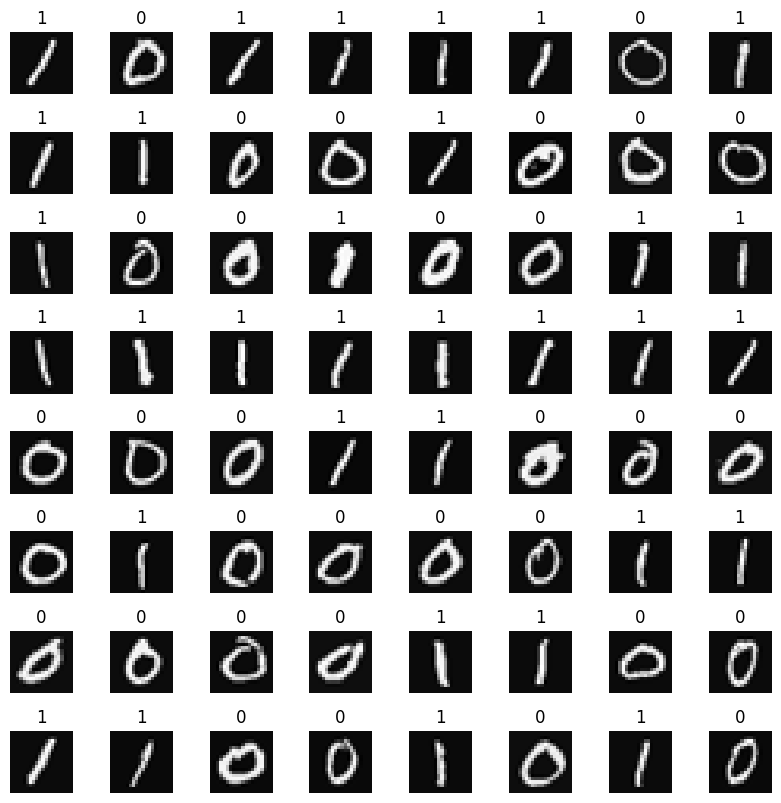

In [6]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# Bạn không cần sửa đổi bất cứ điều gì trong ô này

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1)

for i,ax in enumerate(axes.flat):
    # Chọn chỉ số ngẫu nhiên
    random_index = np.random.randint(m)
    
    # Chọn các hàng tương ứng với các chỉ số ngẫu nhiên và
    # định hình lại hình ảnh
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Hiển thị hình ảnh
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Hiển thị nhãn phía trên hình ảnh
    ax.set_title(y[random_index,0])
    ax.set_axis_off()

<a name="2.3"></a>
### 2.3 Biểu diễn mô hình

Neural network bạn sẽ sử dụng trong bài tập này được hiển thị trong hình bên dưới. 
- Lớp này có ba lớp dày đặc với kích hoạt sigmoid.
    - Hãy nhớ lại rằng đầu vào của chúng ta là giá trị pixel của hình ảnh chữ số.
    - Vì hình ảnh có kích thước $20\times20$, điều này mang lại cho chúng ta đầu vào $400$  
    
<img src="images/C2_W1_Assign1.PNG" width="500" height="400">


- Các tham số có kích thước có kích thước cho neural network với đơn vị $25$ ở lớp 1, $15$ đơn vị ở lớp 2 và $1$ đơn vị đầu ra ở lớp 3. 

    - Nhắc lại kích thước của các tham số này được xác định như sau:
        - Nếu mạng có $s_{in}$ đơn vị trong một lớp và $s_{out}$ đơn vị ở lớp tiếp theo thì 
            - $W$ sẽ có kích thước $s_{in} \times s_{out}$.
            - $b$ sẽ là một vectơ có phần tử $s_{out}$
  
    - Do đó, hình dạng của `W` và `b` là 
        - layer1: Hình dạng của `W1` là (400, 25) và hình dạng của `b1` là (25,)
        - layer2: Hình dạng của `W2` là (25, 15) và hình dạng của `b2` là: (15,)
        - layer3: Hình dạng của `W3` là (15, 1) và hình dạng của `b3` là: (1,)
>**Lưu ý:** Vectơ thiên vị `b` có thể được biểu diễn dưới dạng mảng 1-D (n,) hoặc 2-D (n,1). Tensorflow sử dụng biểu diễn 1-D và Lab này sẽ duy trì quy ước đó.


<a name="2.4"></a>
### 2.4 Triển khai mô hình Tensorflow


Các mô hình Tensorflow được xây dựng từng lớp. Kích thước đầu vào của lớp ($s_{in}$ ở trên) được tính cho bạn. Bạn chỉ định *kích thước đầu ra* của một lớp và điều này sẽ xác định kích thước đầu vào của lớp tiếp theo. Kích thước đầu vào của lớp đầu tiên được lấy từ kích thước của dữ liệu đầu vào được chỉ định trong thống kê `model.fit` bên dưới. 
>**Lưu ý:** Cũng có thể thêm lớp đầu vào để chỉ định kích thước đầu vào của lớp đầu tiên. Ví dụ:  
`tf.keras.Input(shape=(400,)),    #specify input shape`  
chúng ta sẽ đưa điều đó vào đây để làm sáng tỏ một số kích thước mô hình.


<a name="ex01"></a>
### Bài tập 1

Dưới đây, sử dụng Keras [Sequential model](https://keras.io/guides/sequential_model/) và [Dense Layer](https://keras.io/api/layers/core_layers/dense/) với kích hoạt sigmoid để xây dựng mạng được mô tả ở trên.


In [7]:
# UNQ_C1
# GRADED CELL: Sequential model

model = Sequential(
    [               
        tf.keras.Input(shape=(400,)),    #specify input size
        # ## BẮT ĐẦU MÃ TẠI ĐÂY ###
        tf.keras.layers.Dense(25, activation="sigmoid"),
        tf.keras.layers.Dense(15, activation="sigmoid"),
        tf.keras.layers.Dense(1, activation="sigmoid")
        # ## KẾT THÚC MÃ TẠI ĐÂY ###
    ], name = "my_model" 
)                            


In [8]:
model.summary()

Model: "my_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 25)                10025     
                                                                 
 dense_1 (Dense)             (None, 15)                390       
                                                                 
 dense_2 (Dense)             (None, 1)                 16        
                                                                 
Total params: 10431 (40.75 KB)
Trainable params: 10431 (40.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


<details>
  <summary><font size="3" color="darkgreen"><b>Đầu ra dự kiến (Nhấp để mở rộng) </b></font></summary>
Hàm `model.summary()` hiển thị bản tóm tắt hữu ích của mô hình. Bởi vì chúng ta đã chỉ định kích thước lớp đầu vào, hình dạng của mảng trọng số và độ lệch được xác định và tổng số tham số trên mỗi lớp có thể được hiển thị. Lưu ý, tên của các lớp có thể thay đổi khi chúng được tạo tự động.  
    
    
```
Model: "my_model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
dense (Dense)                (None, 25)                10025     
_________________________________________________________________
dense_1 (Dense)              (None, 15)                390       
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 16        
=================================================================
Total params: 10,431
Trainable params: 10,431
Non-trainable params: 0
_________________________________________________________________
```


<details>
  <summary><font size="3" color="darkgreen"><b>Nhấp để xem gợi ý</b></font></summary>
Như đã mô tả trong bài giảng:
    
```python
model = Sequential(                      
    [                                   
        tf.keras.Input(shape=(400,)),    # specify input size (optional)
        Dense(25, activation='sigmoid'), 
        Dense(15, activation='sigmoid'), 
        Dense(1,  activation='sigmoid')  
    ], name = "my_model"                                    
)                                       
```


In [9]:
# KIỂM TRA ĐƠN VỊ
from public_tests import * 

test_c1(model)

All tests passed!


Số lượng tham số hiển thị trong bản tóm tắt tương ứng với số phần tử trong mảng trọng số và độ lệch như hình dưới đây.


In [10]:
L1_num_params = 400 * 25 + 25  # W1 parameters  + b1 parameters
L2_num_params = 25 * 15 + 15   # W2 parameters  + b2 parameters
L3_num_params = 15 * 1 + 1     # W3 parameters  + b3 parameters
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params, ",  L3 params = ", L3_num_params )

L1 params =  10025 , L2 params =  390 ,  L3 params =  16


Chúng ta hãy kiểm tra thêm các trọng số để xác minh rằng tensorflow tạo ra các kích thước giống như chúng ta đã tính toán ở trên.


In [11]:
[layer1, layer2, layer3] = model.layers

In [12]:
# ### Kiểm tra hình dạng của weight
W1,b1 = layer1.get_weights()
W2,b2 = layer2.get_weights()
W3,b3 = layer3.get_weights()
print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")

W1 shape = (400, 25), b1 shape = (25,)
W2 shape = (25, 15), b2 shape = (15,)
W3 shape = (15, 1), b3 shape = (1,)


**Đầu ra dự kiến**
```
W1 shape = (400, 25), b1 shape = (25,)  
W2 shape = (25, 15), b2 shape = (15,)  
W3 shape = (15, 1), b3 shape = (1,)
```


`xx.get_weights` trả về mảng NumPy. Người ta cũng có thể truy cập trực tiếp các trọng số ở dạng tensor của chúng. Lưu ý hình dạng của các tensor ở lớp cuối cùng.


In [13]:
print(model.layers[2].weights)

[<tf.Variable 'dense_2/kernel:0' shape=(15, 1) dtype=float32, numpy=
array([[-0.54168624],
       [-0.09093481],
       [ 0.1507231 ],
       [ 0.592032  ],
       [ 0.48320085],
       [-0.34782892],
       [-0.12345943],
       [-0.21037045],
       [-0.23828089],
       [-0.60355735],
       [-0.02080935],
       [-0.13894781],
       [ 0.334015  ],
       [ 0.3833844 ],
       [-0.33802333]], dtype=float32)>, <tf.Variable 'dense_2/bias:0' shape=(1,) dtype=float32, numpy=array([0.], dtype=float32)>]


Đoạn mã sau sẽ xác định hàm loss mát và chạy gradient descent để khớp trọng số của mô hình với dữ liệu training. Điều này sẽ được giải thích chi tiết hơn vào tuần sau.


In [ ]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(0.001),
)

model.fit(
    X,
    y,
    epochs=20
)

Epoch 1/20
32/32 [==============================] - 0s 930us/step - loss: 0.6509
Epoch 2/20
32/32 [==============================] - 0s 867us/step - loss: 0.4908
Epoch 3/20
32/32 [==============================] - 0s 873us/step - loss: 0.3434
Epoch 4/20
32/32 [==============================] - 0s 790us/step - loss: 0.2341
Epoch 5/20
32/32 [==============================] - 0s 788us/step - loss: 0.1674
Epoch 6/20
32/32 [==============================] - 0s 953us/step - loss: 0.1271
Epoch 7/20
32/32 [==============================] - 0s 950us/step - loss: 0.1012
Epoch 8/20
32/32 [==============================] - 0s 818us/step - loss: 0.0834
Epoch 9/20
32/32 [==============================] - 0s 835us/step - loss: 0.0703
Epoch 10/20
32/32 [==============================] - 0s 862us/step - loss: 0.0603
Epoch 11/20
32/32 [==============================] - 0s 985us/step - loss: 0.0526
Epoch 12/20
32/32 [==============================] - 0s 1ms/step - loss: 0.0466
Epoch 13/20
32/32 [========

Để chạy mô hình trên một ví dụ nhằm đưa ra dự đoán, hãy sử dụng [Keras `predict`](https://www.tensorflow.org/api_docs/python/tf/keras/Model). Đầu vào của `predict` là một mảng nên ví dụ đơn lẻ được định hình lại thành hai chiều.


In [15]:
prediction = model.predict(X[0].reshape(1,400))  # a zero
print(f" predicting a zero: {prediction}")
prediction = model.predict(X[500].reshape(1,400))  # a one
print(f" predicting a one:  {prediction}")

1/1 [==============================] - 0s 72ms/step
 predicting a zero: [[0.01253794]]
1/1 [==============================] - 0s 38ms/step
 predicting a one:  [[0.9756287]]


Đầu ra của mô hình được hiểu là một xác suất. Trong ví dụ đầu tiên ở trên, đầu vào là số 0. Mô hình dự đoán xác suất đầu vào là 1 gần như bằng 0. 
Trong ví dụ thứ hai, đầu vào là một. Mô hình dự đoán xác suất đầu vào là một gần bằng một.
Như trong trường hợp logistic regression, xác suất được so sánh với ngưỡng để đưa ra dự đoán cuối cùng.


In [16]:
if prediction >= 0.5:
    yhat = 1
else:
    yhat = 0
print(f"prediction after threshold: {yhat}")

prediction after threshold: 1


Hãy so sánh dự đoán với nhãn cho một mẫu ngẫu nhiên gồm 64 chữ số. Việc này cần một chút thời gian để chạy.


1/1 [==============================] - 0s 17ms/step


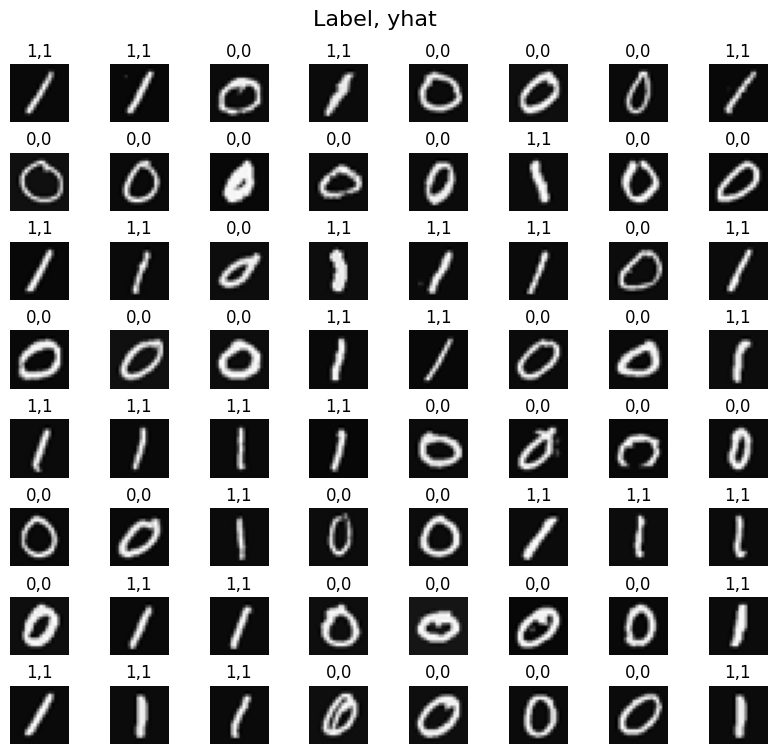

In [17]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# Bạn không cần sửa đổi bất cứ điều gì trong ô này

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1,rect=[0, 0.03, 1, 0.92]) #[left, bottom, right, top]

for i,ax in enumerate(axes.flat):
    # Chọn chỉ số ngẫu nhiên
    random_index = np.random.randint(m)
    
    # Chọn các hàng tương ứng với các chỉ số ngẫu nhiên và
    # định hình lại hình ảnh
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Hiển thị hình ảnh
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Dự đoán bằng cách sử dụng Mạng thần kinh
    prediction = model.predict(X[random_index].reshape(1,400))
    if prediction >= 0.5:
        yhat = 1
    else:
        yhat = 0
    
    # Hiển thị nhãn phía trên hình ảnh
    ax.set_title(f"{y[random_index,0]},{yhat}")
    ax.set_axis_off()
fig.suptitle("Label, yhat", fontsize=16)
plt.show()

<a name="2.5"></a>
### 2.5 NumPy Triển khai mô hình (Chuyển tiếp Prop trong NumPy)
Như đã mô tả trong bài giảng, bạn có thể xây dựng lớp dày đặc của riêng mình bằng cách sử dụng NumPy. Sau đó, điều này có thể được sử dụng để xây dựng neural network nhiều lớp. 

<img src="images/C2_W1_dense2.PNG" width="600" height="450">


<a name="ex02"></a>
### Bài tập 2

Dưới đây, xây dựng một chương trình con lớp dày đặc. Ví dụ trong bài giảng sử dụng vòng lặp for để truy cập từng đơn vị (`j`) trong lớp và thực hiện Tích dot của các trọng số cho đơn vị đó (`W[:,j]`) và tính tổng độ lệch cho đơn vị (`b[j]`) để tạo thành `z`. Sau đó, hàm kích hoạt `g(z)` sẽ được áp dụng cho kết quả đó. Phần này sẽ không sử dụng một số phép toán ma trận được mô tả trong các bài giảng tùy chọn. Những điều này sẽ được khám phá ở phần sau.


In [19]:
# UNQ_C2
# GRADED FUNCTION: my_dense

def my_dense(a_in, W, b, g):
    """
    Computes dense layer
    Args:
      a_in (ndarray (n, )) : Data, 1 example 
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (j, )) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    Returns
      a_out (ndarray (j,))  : j units
    """
    units = W.shape[1]
    a_out = np.zeros(units)
# ## BẮT ĐẦU MÃ TẠI ĐÂY ###
    for i in range(units):
        w = W[:,i]
        z=np.dot(w,a_in) + b[i]
        a_out[i]=g(z)
# ## KẾT THÚC MÃ TẠI ĐÂY ###
    return(a_out)

In [20]:
# Kiểm tra nhanh
x_tst = 0.1*np.arange(1,3,1).reshape(2,)  # (1 examples, 2 features)
W_tst = 0.1*np.arange(1,7,1).reshape(2,3) # (2 input features, 3 output features)
b_tst = 0.1*np.arange(1,4,1).reshape(3,)  # (3 features)
A_tst = my_dense(x_tst, W_tst, b_tst, sigmoid)
print(A_tst)

[0.54735762 0.57932425 0.61063923]


**Đầu ra dự kiến**
```
[0.54735762 0.57932425 0.61063923]
```


<details>
  <summary><font size="3" color="darkgreen"><b>Nhấp để xem gợi ý</b></font></summary>
Như đã mô tả trong bài giảng:
    
```python
def my_dense(a_in, W, b, g):
    """
    Computes dense layer
    Args:
      a_in (ndarray (n, )) : Data, 1 example 
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (j, )) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    Returns
      a_out (ndarray (j,))  : j units
    """
    units = W.shape[1]
    a_out = np.zeros(units)
    for j in range(units):             
        w =                            # Select weights for unit j. These are in column j of W
        z =                            # dot product of w and a_in + b
        a_out[j] =                     # apply activation to z
    return(a_out)
```
   
    
<details>
  <summary><font size="3" color="darkgreen"><b>Nhấp để biết thêm gợi ý</b></font></summary>

    
```python
def my_dense(a_in, W, b, g):
    """
    Computes dense layer
    Args:
      a_in (ndarray (n, )) : Data, 1 example 
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (j, )) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    Returns
      a_out (ndarray (j,))  : j units
    """
    units = W.shape[1]
    a_out = np.zeros(units)
    for j in range(units):             
        w = W[:,j]                     
        z = np.dot(w, a_in) + b[j]     
        a_out[j] = g(z)                
    return(a_out)
```


In [21]:
# KIỂM TRA ĐƠN VỊ
test_c2(my_dense)

All tests passed!


Ô sau xây dựng neural network ba lớp bằng cách sử dụng chương trình con `my_dense` ở trên.


In [22]:
def my_sequential(x, W1, b1, W2, b2, W3, b3):
    a1 = my_dense(x,  W1, b1, sigmoid)
    a2 = my_dense(a1, W2, b2, sigmoid)
    a3 = my_dense(a2, W3, b3, sigmoid)
    return(a3)

Chúng ta có thể sao chép các trọng số và độ lệch đã được training từ Tensorflow.


In [23]:
W1_tmp,b1_tmp = layer1.get_weights()
W2_tmp,b2_tmp = layer2.get_weights()
W3_tmp,b3_tmp = layer3.get_weights()

In [24]:
# đưa ra dự đoán
prediction = my_sequential(X[0], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp )
if prediction >= 0.5:
    yhat = 1
else:
    yhat = 0
print( "yhat = ", yhat, " label= ", y[0,0])
prediction = my_sequential(X[500], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp )
if prediction >= 0.5:
    yhat = 1
else:
    yhat = 0
print( "yhat = ", yhat, " label= ", y[500,0])

yhat =  0  label=  0
yhat =  1  label=  1


Chạy ô sau để xem dự đoán từ cả mô hình Numpy và mô hình Tensorflow. Việc này cần một chút thời gian để chạy.


1/1 [==============================] - 0s 13ms/step


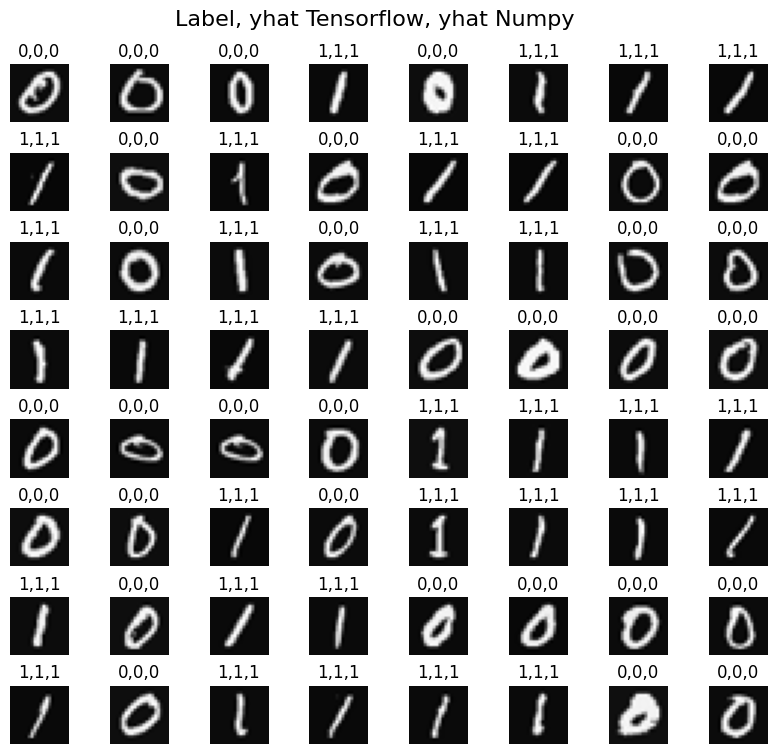

In [25]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# Bạn không cần sửa đổi bất cứ điều gì trong ô này

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1,rect=[0, 0.03, 1, 0.92]) #[left, bottom, right, top]

for i,ax in enumerate(axes.flat):
    # Chọn chỉ số ngẫu nhiên
    random_index = np.random.randint(m)
    
    # Chọn các hàng tương ứng với các chỉ số ngẫu nhiên và
    # định hình lại hình ảnh
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Hiển thị hình ảnh
    ax.imshow(X_random_reshaped, cmap='gray')

    # Dự đoán bằng cách sử dụng Mạng thần kinh được triển khai trong Numpy
    my_prediction = my_sequential(X[random_index], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp )
    my_yhat = int(my_prediction >= 0.5)

    # Dự đoán bằng cách sử dụng Mạng thần kinh được triển khai trong Tensorflow
    tf_prediction = model.predict(X[random_index].reshape(1,400))
    tf_yhat = int(tf_prediction >= 0.5)
    
    # Hiển thị nhãn phía trên hình ảnh
    ax.set_title(f"{y[random_index,0]},{tf_yhat},{my_yhat}")
    ax.set_axis_off() 
fig.suptitle("Label, yhat Tensorflow, yhat Numpy", fontsize=16)
plt.show()

<a name="2.6"></a>
### 2.6 Triển khai mô hình được Vectorized NumPy (Tùy chọn)
Các bài giảng tùy chọn mô tả các phép toán vectơ và ma trận có thể được sử dụng để tăng tốc độ tính toán.
Dưới đây mô tả thao tác lớp tính toán đầu ra cho tất cả các đơn vị trong một lớp trên một ví dụ đầu vào nhất định:

<img src="images/C2_W1_VectorMatrix.PNG" width="600" height="450">

Chúng ta có thể chứng minh điều này bằng cách sử dụng các ví dụ `X` và các tham số `W1`,`b1` ở trên. Chúng ta sử dụng `np.matmul` để thực hiện phép nhân ma trận. Lưu ý, kích thước của x và W phải tương thích như sơ đồ trên.


In [26]:
x = X[0].reshape(-1,1)         # column vector (400,1)
z1 = np.matmul(x.T,W1) + b1    # (1,400)(400,25) = (1,25)
a1 = sigmoid(z1)
print(a1.shape)

(1, 25)


Bạn có thể tiến thêm một bước nữa và tính toán tất cả các đơn vị cho tất cả các ví dụ trong một thao tác Ma trận-Ma trận.

<img src="images/C2_W1_MatrixMatrix.PNG" width="600" height="450">

Hoạt động đầy đủ là
$\mathbf{Z}=\mathbf{XW}+\mathbf{b}$
Điều này sẽ sử dụng feature phát sóng NumPy để mở rộng các hàng $\mathbf{b}$ thành $m$. Nếu bạn chưa quen với điều này, một hướng dẫn ngắn sẽ được cung cấp ở cuối sổ tay.


<a name="ex03"></a>
### Bài tập 3

Dưới đây, hãy soạn một chương trình con `my_dense_v` mới để thực hiện các phép tính lớp cho một ma trận các ví dụ. Điều này sẽ sử dụng `np.matmul()`.


In [29]:
# UNQ_C3
# GRADED FUNCTION: my_dense_v

def my_dense_v(A_in, W, b, g):
    """
    Computes dense layer
    Args:
      A_in (ndarray (m,n)) : Data, m examples, n features each
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (1,j)) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    Returns
      A_out (ndarray (m,j)) : m examples, j units
    """
# ## BẮT ĐẦU MÃ TẠI ĐÂY ###
    A_out = g(np.matmul(A_in,W) + b)
# ## KẾT THÚC MÃ TẠI ĐÂY ###
    return(A_out)

In [30]:
X_tst = 0.1*np.arange(1,9,1).reshape(4,2) # (4 examples, 2 features)
W_tst = 0.1*np.arange(1,7,1).reshape(2,3) # (2 input features, 3 output features)
b_tst = 0.1*np.arange(1,4,1).reshape(1,3) # (1, 3 features)
A_tst = my_dense_v(X_tst, W_tst, b_tst, sigmoid)
print(A_tst)

tf.Tensor(
[[0.54735762 0.57932425 0.61063923]
 [0.57199613 0.61301418 0.65248946]
 [0.5962827  0.64565631 0.6921095 ]
 [0.62010643 0.67699586 0.72908792]], shape=(4, 3), dtype=float64)


**Đầu ra dự kiến**

```
[[0.54735762 0.57932425 0.61063923]
 [0.57199613 0.61301418 0.65248946]
 [0.5962827  0.64565631 0.6921095 ]
 [0.62010643 0.67699586 0.72908792]]
 ```


<details>
  <summary><font size="3" color="darkgreen"><b>Nhấp để xem gợi ý</b></font></summary>
    Ở dạng ma trận, điều này có thể được viết thành một hoặc hai dòng. 
    
       Z = np.matmul của A_in và W cộng b    
       A_out là g(Z)  
<details>
  <summary><font size="3" color="darkgreen"><b>Nhấp để lấy mã</b></font></summary>

```python
def my_dense_v(A_in, W, b, g):
    """
    Computes dense layer
    Args:
      A_in (ndarray (m,n)) : Data, m examples, n features each
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (j,1)) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    Returns
      A_out (ndarray (m,j)) : m examples, j units
    """
    Z = np.matmul(A_in,W) + b    
    A_out = g(Z)                 
    return(A_out)
```


In [31]:
# KIỂM TRA ĐƠN VỊ
test_c3(my_dense_v)

All tests passed!


Ô sau xây dựng neural network ba lớp bằng cách sử dụng chương trình con `my_dense_v` ở trên.


In [32]:
def my_sequential_v(X, W1, b1, W2, b2, W3, b3):
    A1 = my_dense_v(X,  W1, b1, sigmoid)
    A2 = my_dense_v(A1, W2, b2, sigmoid)
    A3 = my_dense_v(A2, W3, b3, sigmoid)
    return(A3)

Một lần nữa chúng ta có thể sao chép các trọng số và độ lệch đã được training từ Tensorflow.


In [33]:
W1_tmp,b1_tmp = layer1.get_weights()
W2_tmp,b2_tmp = layer2.get_weights()
W3_tmp,b3_tmp = layer3.get_weights()

Hãy cùng đưa ra dự đoán với mô hình mới. Điều này sẽ đưa ra dự đoán về *tất cả các ví dụ cùng một lúc*. Lưu ý hình dạng của đầu ra.


In [34]:
Prediction = my_sequential_v(X, W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp )
Prediction.shape

TensorShape([1000, 1])

Chúng ta sẽ áp dụng ngưỡng 0,5 như trước đây nhưng cho tất cả dự đoán cùng một lúc.

In [35]:
Yhat = (Prediction >= 0.5).numpy().astype(int)
print("predict a zero: ",Yhat[0], "predict a one: ", Yhat[500])

predict a zero:  [0] predict a one:  [1]


Chạy ô sau để xem dự đoán. Điều này sẽ sử dụng những dự đoán mà chúng ta vừa tính toán ở trên. Việc này cần một chút thời gian để chạy.


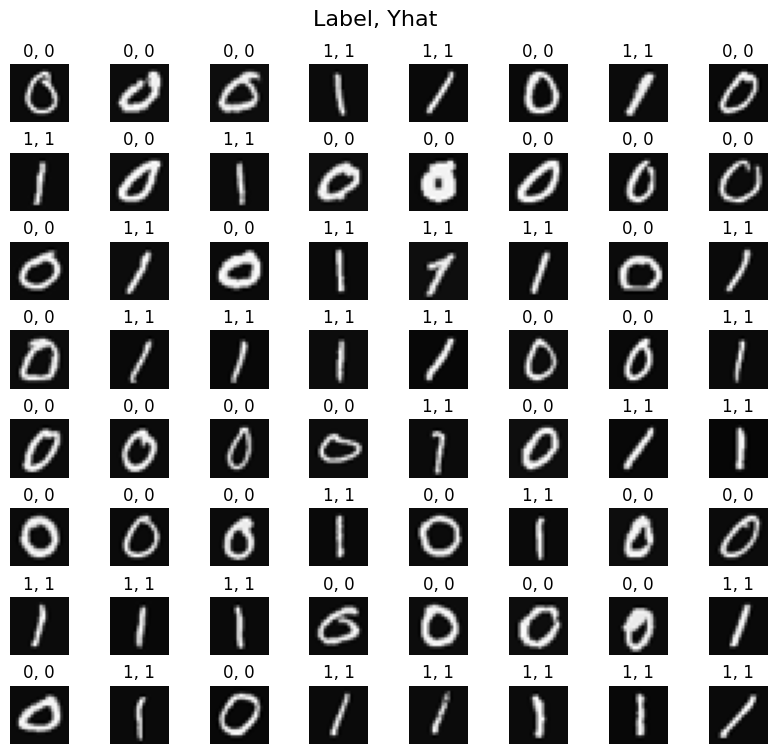

In [36]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# Bạn không cần sửa đổi bất cứ điều gì trong ô này

m, n = X.shape

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.tight_layout(pad=0.1, rect=[0, 0.03, 1, 0.92]) #[left, bottom, right, top]

for i, ax in enumerate(axes.flat):
    # Chọn chỉ số ngẫu nhiên
    random_index = np.random.randint(m)
    
    # Chọn các hàng tương ứng với các chỉ số ngẫu nhiên và
    # định hình lại hình ảnh
    X_random_reshaped = X[random_index].reshape((20, 20)).T
    
    # Hiển thị hình ảnh
    ax.imshow(X_random_reshaped, cmap='gray')
   
    # Hiển thị nhãn phía trên hình ảnh
    ax.set_title(f"{y[random_index,0]}, {Yhat[random_index, 0]}")
    ax.set_axis_off() 
fig.suptitle("Label, Yhat", fontsize=16)
plt.show()

Bạn có thể thấy một trong những hình ảnh bị phân loại sai trông như thế nào.


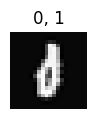

In [37]:
fig = plt.figure(figsize=(1, 1))
errors = np.where(y != Yhat)
random_index = errors[0][0]
X_random_reshaped = X[random_index].reshape((20, 20)).T
plt.imshow(X_random_reshaped, cmap='gray')
plt.title(f"{y[random_index,0]}, {Yhat[random_index, 0]}")
plt.axis('off')
plt.show()

<a name="2.7"></a>
### 2.7 Xin chúc mừng!
Bạn đã xây dựng và sử dụng thành công neural network.


<a name="2.8"></a>
### 2.8 NumPy Hướng dẫn phát sóng (Tùy chọn)


Trong ví dụ trước, $\mathbf{Z}=\mathbf{XW} + \mathbf{b}$ đã sử dụng phát sóng NumPy để mở rộng vectơ $\mathbf{b}$. Nếu bạn chưa quen với NumPy Phát sóng, chúng ta sẽ cung cấp hướng dẫn ngắn này.

$\mathbf{XW}$ là phép toán ma trận-ma trận có chiều $(m,j_1)(j_1,j_2)$ dẫn đến ma trận có chiều $(m,j_2)$. Để làm được điều đó, chúng ta thêm một vectơ $\mathbf{b}$ có kích thước $(1,j_2)$.  $\mathbf{b}$ phải được mở rộng thành ma trận $(m,j_2)$ để phép toán theo phần tử này có ý nghĩa. Việc mở rộng này được thực hiện cho bạn bằng cách phát sóng NumPy.


Việc phát sóng áp dụng cho các hoạt động theo từng phần tử.  
Hoạt động cơ bản của nó là 'kéo dài' một chiều nhỏ hơn bằng cách sao chép các phần tử để phù hợp với chiều lớn hơn.

Thêm [specifically](https://NumPy.org/doc/stable/user/basics.broadcasting.html): 
Khi hoạt động trên hai mảng, NumPy so sánh hình dạng của chúng theo từng phần tử. Nó bắt đầu với các kích thước ở cuối (tức là ngoài cùng bên phải) và hoạt động theo hướng bên trái. Hai chiều tương thích khi
- chúng bằng nhau, hoặc
- một trong số đó là 1   

Nếu những điều kiện này không được đáp ứng, ngoại lệ ValueError: các toán hạng không thể được phát cùng nhau sẽ được đưa ra, cho biết rằng các mảng có hình dạng không tương thích. Kích thước của mảng kết quả là kích thước không bằng 1 dọc theo mỗi trục của đầu vào.

Dưới đây là một số ví dụ:


<figure>
    <center> <img src="./images/C2_W1_Assign1_BroadcastIndexes.PNG"  alt='missing' width="400"  ><center/>
    <figcaption>Tính toán hình dạng Kết quả phát sóng</figcaption>
<figure/>


Hình ảnh bên dưới mô tả các kích thước mở rộng. Lưu ý dòng chữ màu đỏ bên dưới:


<figure>
    <center> <img src="./images/C2_W1_Assign1_Broadcasting.gif"  alt='missing' width="600"  ><center/>
    <figcaption>Broadcast mở rộng các đối số một cách khái niệm để phù hợp với các hoạt động thông minh của phần tử</figcaption>
<figure/>


Hình ảnh trên cho thấy NumPy mở rộng các đối số cho phù hợp trước thao tác cuối cùng. Lưu ý rằng đây là một mô tả mang tính khái niệm. Cơ chế thực tế của hoạt động NumPy chọn cách triển khai hiệu quả nhất.

Đối với mỗi ví dụ sau, hãy thử đoán kích thước của kết quả trước khi chạy ví dụ.


In [38]:
a = np.array([1,2,3]).reshape(-1,1)  #(3,1)
b = 5
print(f"(a + b).shape: {(a + b).shape}, \na + b = \n{a + b}")

(a + b).shape: (3, 1), 
a + b = 
[[6]
 [7]
 [8]]


Lưu ý rằng điều này áp dụng cho tất cả các hoạt động theo từng phần tử:


In [39]:
a = np.array([1,2,3]).reshape(-1,1)  #(3,1)
b = 5
print(f"(a * b).shape: {(a * b).shape}, \na * b = \n{a * b}")

(a * b).shape: (3, 1), 
a * b = 
[[ 5]
 [10]
 [15]]


<figure>
    <img src="./images/C2_W1_Assign1_VectorAdd.PNG"  alt='missing' width="740" >
    <center><figcaption><b>Các thao tác thông minh theo phần tử hàng-cột</b></figcaption></center>
<figure/>


In [40]:
a = np.array([1,2,3,4]).reshape(-1,1)
b = np.array([1,2,3]).reshape(1,-1)
print(a)
print(b)
print(f"(a + b).shape: {(a + b).shape}, \na + b = \n{a + b}")

[[1]
 [2]
 [3]
 [4]]
[[1 2 3]]
(a + b).shape: (4, 3), 
a + b = 
[[2 3 4]
 [3 4 5]
 [4 5 6]
 [5 6 7]]


Đây là kịch bản trong lớp dày đặc mà bạn đã xây dựng ở trên. Thêm vectơ 1-D $b$ vào ma trận (m,j).
<figure>
    <img src="./images/C2_W1_Assign1_BroadcastMatrix.PNG"  alt='missing' width="740" >
    <center><figcaption><b>Ma trận + Vectơ 1-D</b></figcaption></center>
<figure/>
